In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os
os.makedirs("figures/Supplement_figures/Inference_RC", exist_ok=True)

In [3]:
simpath = "result/5_simulate_from_calibrated_params"
datapath = "Data/filtered_data_v6"
Inf_respath = "result/2_run_inference"
rc = 40
kon = 1.15
fitted_offset = 1.619950532913208

In [4]:
conditions = ["340kb_Ce_Cp", "85kb", "170kb", "340kb_Ce", "255kb", "340kb_Cp", "340kb"]
condition_labels = ["339CECP","87noC","170noC","339CE","253noC","339CP","339noC"]

In [5]:
ms2_obs,sim_ms2 = [],[]
pons = []
for condition in conditions:
    filename = f"{simpath}/simulated_data_{condition}_None_30s_rc{rc}_kon{kon}.pkl"
    with open(filename, "rb") as f:
        data = pickle.load(f)
        ms2 = data["ms2_noisy_dat"]
        sim_ms2.append(ms2+fitted_offset)
    dpath = f"{datapath}/30s_{condition}_None.npz"    
    dat = np.load(dpath)
    ms2_obs.append(dat["corrected_intensity"])
    file_path = f"{Inf_respath}/{condition}/None/rc={rc}/30s_{condition}_None_rc={rc}_kon={kon}_model_object.pkl"
    with open(file_path, "rb") as f:
        model_object = pickle.load(f)
        pon = model_object.M.get("Promoter State")["masked_posterior"][1:,:,0].T
    pons.append(pon)

In [6]:
colors_pt = {
        "blue": "#0077BB",
        "magenta": "#EE3377",
        "teal": "#009988",
        "orange": "#EE7733",
        "cyan": "#33BBEE",
        "red": "#CC3311",
        "grey": "#BBBBBB",
    }


from matplotlib.colors import LinearSegmentedColormap


pt_heatmap_cmap = LinearSegmentedColormap.from_list(
    "PT_Inferno",
    [
        (0.00, "#000000"),
        (0.35, colors_pt["blue"]),
        (0.65, colors_pt["magenta"]),
        (0.85, colors_pt["orange"]),
        (1.00, "#FFDDAA"),
    ],
)


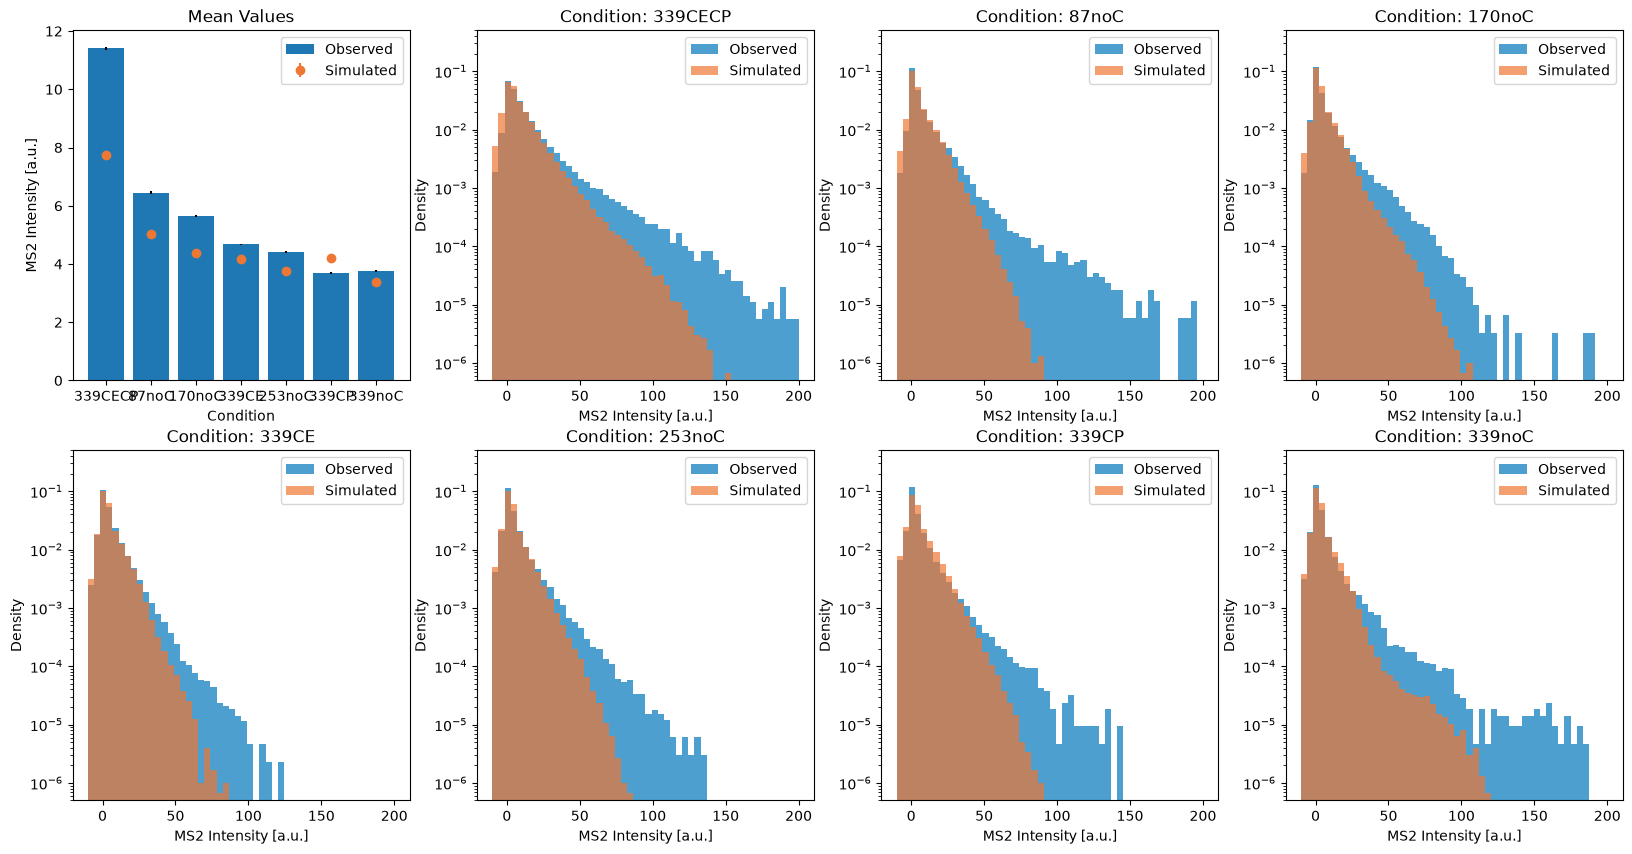

In [16]:
fig,ax = plt.subplots(2,4,figsize=(20,10))
ms2_min,ms2_max = -10,200
nbins = 50
for i, (obs, sim) in enumerate(zip(ms2_obs, sim_ms2)):
    ax.flatten()[i+1].hist(obs.flatten(), label="Observed",density=True,bins=nbins,range=(ms2_min,ms2_max),alpha=0.7,color=colors_pt["blue"])
    ax.flatten()[i+1].hist(sim.flatten(), label="Simulated",density=True,bins=nbins,range=(ms2_min,ms2_max),alpha=0.7,color=colors_pt["orange"])
    ax.flatten()[i+1].set(title=f"Condition: {condition_labels[i]}",yscale="log",ylim=(5e-7,5e-1),xlabel="MS2 Intensity [a.u.]",ylabel="Density")
    ax.flatten()[i+1].legend()
obs_mean, sim_mean = [np.nanmean(obs.flatten()) for obs in ms2_obs], [np.nanmean(sim.flatten()) for sim in sim_ms2]
std_obs, std_sim = [np.nanstd(obs.flatten())/np.sqrt(len(obs.flatten())) for obs in ms2_obs], [np.nanstd(sim.flatten())/np.sqrt(len(sim.flatten())) for sim in sim_ms2]
ax.flatten()[0].bar(condition_labels, obs_mean, yerr=std_obs, label="Observed")
ax.flatten()[0].errorbar(condition_labels, sim_mean, yerr=std_sim,fmt="o", label="Simulated",color=colors_pt["orange"])
ax.flatten()[0].set(title="Mean Values", ylabel="MS2 Intensity [a.u.]",xlabel="Condition")
ax.flatten()[0].legend()
fig.savefig("figures/Supplement_figures/Inference_RC/ms2_histograms.pdf", bbox_inches="tight")